# S3 - Aggregating Data and Using Pivot Tables
----

Here, we will see how we can aggregate data using python and the pandas package specifically. This is hopefully where the benefits of Python over tools such as Excel which you might be more familiar with. 

*What do we mean by **Aggregating Data**?*
We usually want to collect the most granular data possible (meaning most fine grained). For example, we want to track every movement on your cell phone (or any GPS technology), every text document, every observation, etc. This leads to *"big data"* where we have datasets with many rows. However, we usually only want highly aggregated information (average of these values over the whole dataset). This is where python is very useful. This is the type of information that business analysts and data scientists are in charge of providing. 

*Why Pivot Tables?*
There are many ways to do this. However, I think that the most intuitive approach is to use pivot tables as this is very flexible and you can apply the commands belowto any situation. 


In [ ]:
# Loading the Pandas Packages # 

import pandas as pd

import numpy as np 

from google.colab import drive                          

import os 

We will need a dataset so I will load the same file we used in the past (S2). 

# S3.1 - Let's load the dataset located on Google Drive

In [ ]:
# Then we load our drive - You might have to follow along on some intermediate steps #

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# We change directory to the directory below - This will differ on your system #

os.chdir("./drive/MyDrive/Teaching/DSO 574/Notebooks for Python Workshops/Data Files")

To see the files, just type *ls*

In [ ]:
ls

 LA2020listings.csv         LA2020reviews.csv
 LA2020neighbourhoods.csv  'Max Listing Price Per Neig and RT.png'


In [ ]:
# We will use the Los Angeles Listings Data called LA2020listings.csv

data = pd.read_csv("./LA2020listings.csv")


# S3.2 - Exploring the Data
----

Here, I will repeat some of the commands from S2 that we will use to remind ourselves of the data. This is often useful whenever you get into a dataset as you want to confirm what the variables are called, or what are the different groups in the dataset. 

In [ ]:
# Seeing the Columns (Variable Names) that we have in the data #

data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [ ]:
# To see what the data looks like, we can use the .head() command which gives the first five rows of the datasset # 

data.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,109,Amazing bright elegant condo park front *UPGRA...,521,Paolo,Other Cities,Culver City,33.98209,-118.38494,Entire home/apt,115,30,2,2016-05-15,0.02,1,216
1,2708,Beautiful Furnish Mirrored Mini-Suite w/ Firep...,3008,Chas.,City of Los Angeles,Hollywood,34.09768,-118.34602,Private room,71,30,27,2020-10-06,0.35,2,360
2,2732,Zen Life at the Beach,3041,Yoga Priestess,Other Cities,Santa Monica,34.00475,-118.48127,Private room,155,1,21,2019-12-27,0.18,2,337
3,2864,* Beautiful Master Suite/Jacuzzi Tub/*,3207,Bernadine,Other Cities,Bellflower,33.87619,-118.11397,Entire home/apt,50,30,0,NaN,NaN,1,0
4,5728,Tiny Home in Artistic Oasis near Venice and LAX,9171,Sanni,City of Los Angeles,Del Rey,33.98750,-118.43200,Private room,60,30,310,2020-04-29,2.25,5,337


We can use the .value_counts() command to understand the different observations that occur in categorical (group) variables

In [ ]:
# For example, the different types of appartments. 

data['room_type'].value_counts(ascending = True)

Hotel room           156
Shared room         1042
Private room        9981
Entire home/apt    20292
Name: room_type, dtype: int64

We can see that the majority are Entire home / appartments, and the other ones are more niche. Later we will select only these groups. 

In [ ]:
# We can also see the neighborhoods in our dataset (We add .head(10) to give us the top 10 # 

data['neighbourhood'].value_counts(ascending = False).head(10)

Long Beach         1615
Venice             1569
Hollywood          1547
Santa Monica       1168
Downtown           1089
Hollywood Hills     702
West Hollywood      639
Glendale            537
Beverly Hills       504
Rowland Heights     497
Name: neighbourhood, dtype: int64

# S3.3 - Selecting the section of the data we want to use
---

What you might realize from looking at the data above is that we might only care about some of these observations. For example, we might only want to select *whole home / apt*  listings and select ones that are in certain neighborhoods.  

We covered using the .loc commands in S2.

In [ ]:
# Select only listings which are "whole home / apt" #

workingdata = data.loc[data['room_type'] == 'Entire home/apt']

In [ ]:
# Select only certain neighbourhoods - There are two approaches #

# Approach 1 - Write a conditional statement that indicates the different neighborhoods that you are considering. Notice that we are using the | opperator which indicates "or"
# in the sense that we are saying if the neighbourhood is Santa Monica "or" Venice "or" Downtown 

workingdata = workingdata.loc[(workingdata['neighbourhood'] == 'Santa Monica')|(workingdata['neighbourhood'] == 'Venice')|(workingdata['neighbourhood'] == 'Downtown')]

# Approach 2 - Create a separate dataset for each and combine using pd.concat #. 

SM = workingdata.loc[(workingdata['neighbourhood'] == 'Santa Monica')]
VN = workingdata.loc[(workingdata['neighbourhood'] == 'Venice')]
DT = workingdata.loc[(workingdata['neighbourhood'] == 'Downtown')]

workingdata = pd.concat([SM, VN, DT])


I'm showing you two approaches above for several reasons. 


*   It's helpful to see that you can get at the same outcome with different approaches.
*   I have had several students encounter a situation where they want to combine different dataframes.

Let's just double check that we have done this correctly. 



In [ ]:
workingdata['neighbourhood'].value_counts(ascending = False).head(10)

Venice          1318
Downtown         890
Santa Monica     873
Name: neighbourhood, dtype: int64

In [ ]:
workingdata['room_type'].value_counts(ascending = False).head(10)

Entire home/apt    3081
Name: room_type, dtype: int64

Notice that in comaprison to when we ran these command earlier, we are now only seeing the rows we wanted to get. Now we can move forward in terms of aggregating the data. 

#S3.4 - Aggregating the Data
----

To clarify what I mean by aggregating the data, I want to provide an example. Suppose that we want to calculate the average price for a listing in each of these neighbourhoods. 

We will use the command:  **pd.pivot_table**

If you look at the documentation of this command (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html), you will see the following. 

**pivot_table(data, 
values=None,
index=None, 
columns=None, 
aggfunc='mean', 
fill_value=None, 
margins=False, 
dropna=True, 
margins_name='All', 
observed=False) **


This means that you need to specify the following. 


pd.pivot_table(

  data = NAME_OF_YOUR_DATAFRAME, 


  index = WHICH_VARIABLE_DO_YOU_WANT_TO_REPRESENT_THE_ROWS_OF_THE_FINAL_DATA,

  columns = WHICH_VARIABLE_DO_YOU_WANT_TO_REPRESENT_THE_COLUMNS_OF_THE_FINAL_DATA (OPTIONAL),

  values = WHICH_VARIABLE_SHOULD_WE_AGGREGATE,
  aggfunc = WHICH_AGGREGATION_FUNCTION_SHOULD_WE_USE
  )


This is a bit ugly, but it will become clearer below. 

In [ ]:
# Let's calculate the AVERAGE PRICE BY NEIGHBORHOOD #

pd.pivot_table(data = workingdata, 
               index = 'neighbourhood',
               values = 'price',
               aggfunc = np.mean)

,price
neighbourhood,
Downtown,187.824719
Santa Monica,208.328751
Venice,278.284522


You can see that we have an "Aggregated" dataset with the average price per neighborhood. 

One slight inconvenience is that we have the neighborhood as the row name which is not ideal. To address that, we will add the command .reset_index() which moves the index as a column into the dataset. 

In [ ]:
# We can also aggregate by having the index distributed across the columns # 

pd.pivot_table(data = workingdata, 
               columns = 'neighbourhood',
               values = 'price',
               aggfunc = np.mean )

neighbourhood,Downtown,Santa Monica,Venice
price,187.824719,208.328751,278.284522


#S3.5 - Slightly More Advanced Application
--- 

As an illustration, I want to show you some potentially more advanced applications of this approach. 



In [ ]:
# You can combine the index and column functions in the same pivot table # 

# Step 1. Let's look at only neighbourhoods Santa Monica, Downtown and Venice, but lets look at all of the house types. Lets recreate working data, by selecting those cities 
# but not filtering the room_type

workingdata = data.loc[(data['neighbourhood'] == 'Santa Monica')|(data['neighbourhood'] == 'Venice')|(data['neighbourhood'] == 'Downtown')]

# Step 2. Lets specify the rows of the pivot table as room_type, and the columns as neighbourhood. 

pd.pivot_table(data = workingdata, 
               index = 'room_type',
               columns = 'neighbourhood',
               values = 'price',
               aggfunc = np.mean)

neighbourhood,Downtown,Santa Monica,Venice
room_type,,,
Entire home/apt,187.824719,208.328751,278.284522
Hotel room,109.857143,240.166667,198.714286
Private room,185.316384,152.316547,212.565789
Shared room,80.000000,127.818182,67.187500


This data format can be nice to look at, but its not very useful for data analysis. Normally, you would prefer all groups (neighbourhood, room_type) to be in individual columns, and then a single column with price. 


In [ ]:
# To do this, we remove "columns" part of the function, and specify all of the groups in the index part of the function. 

pd.pivot_table(data = workingdata, 
               index = ['room_type', 'neighbourhood'],
               values = 'price',
               aggfunc = np.mean)

price
room_type       neighbourhood            
Entire home/apt Downtown       187.824719
                Santa Monica   208.328751
                Venice         278.284522
Hotel room      Downtown       109.857143
                Santa Monica   240.166667
                Venice         198.714286
Private room    Downtown       185.316384
                Santa Monica   152.316547
                Venice         212.565789
Shared room     Downtown        80.000000
                Santa Monica   127.818182
                Venice          67.187500

It's important to note that these row labels are somewhat difficult to work with in this format, so after running this function we want to include

.reset_index() as described above (and shown below)

In [ ]:
CollapsedData = pd.pivot_table(data = workingdata, 
                                        index = ['room_type', 'neighbourhood'],
                                        values = 'price',
                                        aggfunc = np.mean).reset_index()

CollapsedData

,room_type,neighbourhood,price
0,Entire home/apt,Downtown,187.824719
1,Entire home/apt,Santa Monica,208.328751
2,Entire home/apt,Venice,278.284522
3,Hotel room,Downtown,109.857143
4,Hotel room,Santa Monica,240.166667
5,Hotel room,Venice,198.714286
6,Private room,Downtown,185.316384
7,Private room,Santa Monica,152.316547
8,Private room,Venice,212.565789
9,Shared room,Downtown,80.000000


#S3.6 - Visualizing Data [Optional - I will be very brief]
--- 

Data visualization is very complex and time consuming. While most other things in python are remarkably simple (in my mind) visualziation is remarkably complex and requires learning specific syntax for packages such as matplotlib and seaborn.

I will provide an illustration for how to do this in python. However, I do not want to provide too much emphasis or suggest that I am expecting you to do this. 



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

You can find the complete documentation for these libraries here: 
- MATPLOTLIB > https://matplotlib.org/api/index.html
- SEABORN > https://seaborn.pydata.org/api.html

Matplotlib is hard to use. Seaborn is a code that makes matplotlib easy to use, so I would suggest you devote all of your efforts to working with Seaborn if you are new to this. 

If interested, I would suggest you start here: https://seaborn.pydata.org/tutorial.html

Keep in mind when doing visualization, you have to think about how you want the final graph to look. 



In our case, I want a bar graph with price on the y axis, and then different room types / neighbourhoods on the x axis. 

The synatax would be sns.barplot as follows (API Documentation here: https://seaborn.pydata.org/generated/seaborn.barplot.html#seaborn.barplot)

sns.barplot(

data = NAME_OF_DATASET,

y = VARIABLE_ON_Y_AXIS,

x = VARIABLE_ON_X_AXIS,

hue = GROUPING_VARIABLE_PLOTTED_ON_X_AXIS

)



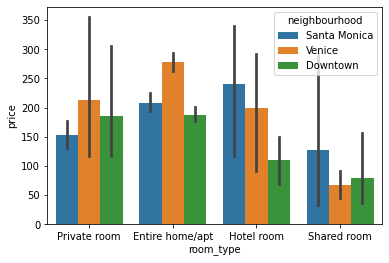

In [ ]:
# Our Goal. Let's graph the average price of rental properties in these geographies. 

sns.barplot(data = workingdata,
                 y = 'price',
                 x = 'room_type',
                 hue = 'neighbourhood')

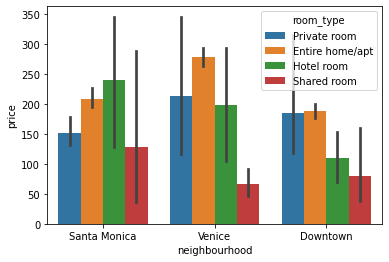

In [ ]:
# We can change whether we are grouping by neighbourhood or by room type by switching the x and hue variables #

sns.barplot(data = workingdata,
                 y = 'price',
                 x = 'neighbourhood',
                 hue = 'room_type')

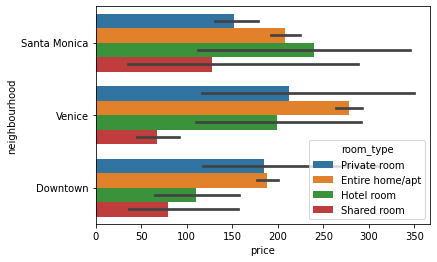

In [ ]:
# We can plot this horizontally if we switch the x and y labels. Python knows what the difference is between the categorical (group variable) and the price variable. 

sns.barplot(data = workingdata,
                 x = 'price',
                 y = 'neighbourhood',
                 hue = 'room_type')

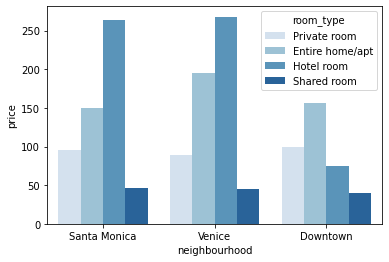

In [ ]:
# If you look into the documentation, you can see the rich way that you can customize the appearance by adding additional functions.

sns.barplot(data = workingdata,
                 y = 'price',
                 x = 'neighbourhood',
                 hue = 'room_type',
                 palette = 'Blues',
                 ci = 0,
                 estimator = np.median
                 )

# For example, 
# Palette = allows us to define the color palette for the figures. Blues, Reds, etc. See: https://seaborn.pydata.org/tutorial/color_palettes.html
# CI = Allows you to draw confidence intervals for the bars telling you how the data is distributed. 
# Estimator = allows you to specify the function you want. np.mean by default. However, here we use np.median to get the median values.

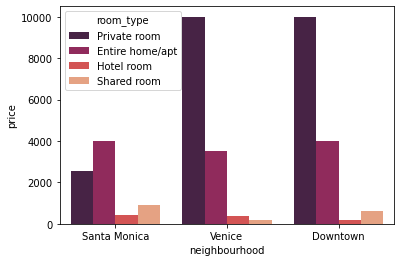

In [ ]:
# You can vary this to create different types of graphs. 

sns.barplot(data = workingdata,
                 y = 'price',
                 x = 'neighbourhood',
                 hue = 'room_type',
                 palette = 'rocket',
                 ci = 0,
                 estimator = np.max
                 )

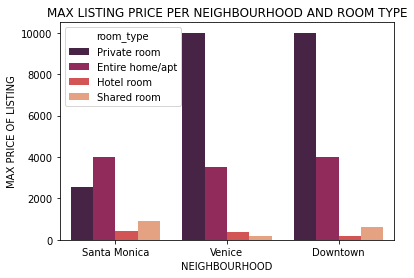

In [ ]:
# If you want to customize it futher you might have to use some matplotlib (ie. plt) commands # 

sns.barplot(data = workingdata,
                 y = 'price',
                 x = 'neighbourhood',
                 hue = 'room_type',
                 palette = 'rocket',
                 ci = 0,
                 estimator = np.max
                 )
# Change X and Y axis labels # 
plt.xlabel("NEIGHBOURHOOD")
plt.ylabel("MAX PRICE OF LISTING")

# Add title to figure # 
plt.title("MAX LISTING PRICE PER NEIGHBOURHOOD AND ROOM TYPE")

# SHow the final graph (It does it without this, but its cleaner with - removes some additional messy text)
plt.show()

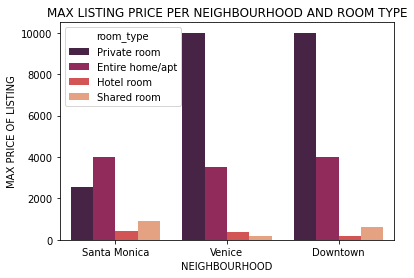

In [ ]:
# to save a graph, run plt.savefig("FILENAME") before the plt.show()

sns.barplot(data = workingdata,
                 y = 'price',
                 x = 'neighbourhood',
                 hue = 'room_type',
                 palette = 'rocket',
                 ci = 0,
                 estimator = np.max
                 )

plt.xlabel("NEIGHBOURHOOD")
plt.ylabel("MAX PRICE OF LISTING")
plt.title("MAX LISTING PRICE PER NEIGHBOURHOOD AND ROOM TYPE")
plt.savefig("./Max Listing Price Per Neig and RT.png")                       
plt.show()

# Next Steps

--- 

The purpose of this workshop was to introduce you to data aggregation. The most useful aspect of this is creating a pivot table that summarizes data. 

*   If you understand how the pivot_table commands work, I would suggest putting in some time to perform some more complex aggregations and explore the other variables as this data will be used for the first assignment.  
*   If you feel that you do not have a grip of aggregating data yet, I suggest reviewing the use of the pivot_table function as that is the most useful part. 
*   If you have any questions / extensions / issues you would like to discuss in the in person session, please let me know and I will try to bring it up in class. 

